In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/archive/combine.csv", low_memory=False)
df.columns = df.columns.str.strip()
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [6]:
df.shape

(2214469, 79)

In [7]:
df['Label'] = df['Label'].str.strip().str.upper()

In [8]:
df['Label'].value_counts()

Label
BENIGN              1672837
DOS HULK             231073
PORTSCAN             158930
DDOS                 128027
DOS GOLDENEYE         10293
DOS SLOWLORIS          5796
DOS SLOWHTTPTEST       5499
BOT                    1966
INFILTRATION             36
HEARTBLEED               11
Name: count, dtype: int64

In [9]:
df['Label']=df['Label'].replace({
    'DOS HULK':'DOS',
    'DOS GOLDENEYE':'DOS',
    'DOS SLOWLORIS':'DOS',
    'DOS SLOWHTTPTEST':'DOS'
})

In [10]:
df = df[df['Label'].isin(['BENIGN','DOS','PORTSCAN','DDOS'])]

In [11]:
print("After removing duplicates:")
print(df['Label'].value_counts())

After removing duplicates:
Label
BENIGN      1672837
DOS          252661
PORTSCAN     158930
DDOS         128027
Name: count, dtype: int64


In [12]:
cols_to_drop = ['Destination Port']
X = df.drop(['Label'] + cols_to_drop, axis=1)

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  
    random_state=42,
    stratify=y
)

In [15]:
train_df = pd.concat([X_train, y_train], axis=1)

In [16]:
min_count = train_df['Label'].value_counts().min()

print("Min class count in train:", min_count)

Min class count in train: 89619


In [17]:
train_df = train_df.groupby('Label', group_keys=False).sample(
    n=min_count,
    random_state=42
)

In [18]:
X_train = train_df.drop('Label', axis=1)
y_train = train_df['Label']

In [19]:
for col in ['Destination Port']:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [20]:
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [21]:
X_train.dropna(inplace=True)
y_train = y_train.loc[X_train.index]

In [22]:
X_test.dropna(inplace=True)
y_test = y_test.loc[X_test.index]

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,   
    max_depth=5,            
    min_samples_leaf=10,    
    random_state=42
)


In [27]:
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.9773725831484417

               precision    recall  f1-score   support

           0       1.00      0.97      0.99    501452
           1       0.99      1.00      0.99     38408
           2       0.85      0.99      0.91     75508
           3       0.99      0.99      0.99     47633

    accuracy                           0.98    663001
   macro avg       0.96      0.99      0.97    663001
weighted avg       0.98      0.98      0.98    663001



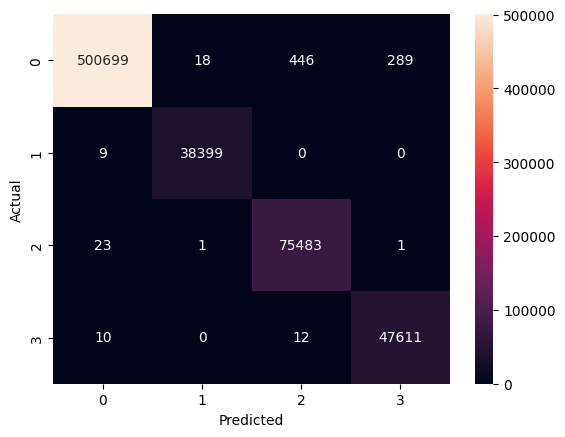

In [159]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')